# Day 10: Inventory Optimization 

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.optimization.inventory import (
    compute_abc_classification, compute_product_demand_stats, compute_safety_stock,
    compute_reorder_point, compute_eoq, build_inventory_recommendations, simulate_reorder_trigger,write_recommendations,
    LEAD_TIME_DAYS, SERVICE_LEVEL, ORDER_COST, HOLDING_COST_RATE,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

df = pd.read_csv("../data/processed/completed_sales.csv")
df["invoice_date"] = pd.to_datetime(df["invoice_date"])
print(f"{df['stock_code'].nunique():,} distinct products")

4,902 distinct products


## Assumptions 

| Parameter | Value | Why |
|---|---|---|
| Lead time | 7 days | Generic supplier assumption; real value should come from procurement |
| Service level | 95% | Common retail target |
| Order cost | £20/PO | Generic flat cost |
| Holding cost rate | 20%/year of unit price | Standard retail heuristic, proxies true holding cost |


## ABC classification

In [2]:
abc = compute_abc_classification(df)
tier_summary = abc.groupby("tier").agg(n_products=("tier", "size"), total_revenue=("total_revenue", "sum"))
tier_summary["pct_of_skus"] = tier_summary["n_products"] / tier_summary["n_products"].sum() * 100
tier_summary["pct_of_revenue"] = tier_summary["total_revenue"] / tier_summary["total_revenue"].sum() * 100
tier_summary

2026-06-29 19:06:57,485 [INFO] ABC classification: A=1039 products (21.2% of SKUs, 80% of revenue), B=1283, C=2580


,n_products,total_revenue,pct_of_skus,pct_of_revenue
tier,,,,
A,1039,15712365.34,21.195430,79.978983
B,1283,2950654.40,26.172991,15.019402
C,2580,982598.05,52.631579,5.001614


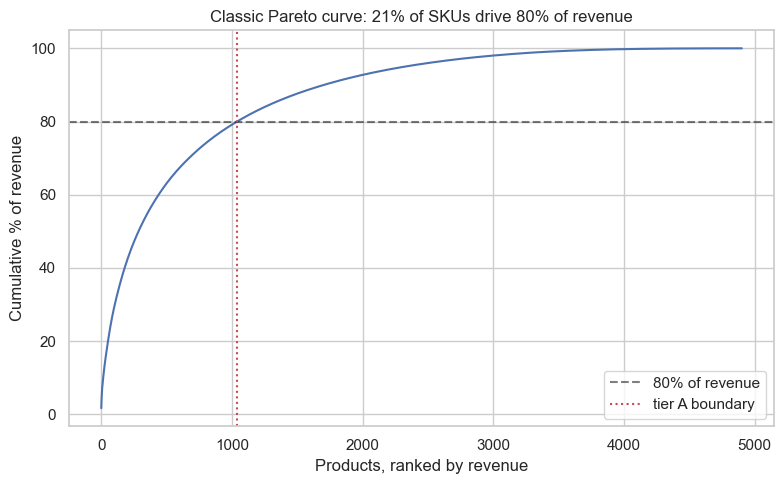

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
sorted_rev = abc["total_revenue"].sort_values(ascending=False).reset_index(drop=True)
cum_share = sorted_rev.cumsum() / sorted_rev.sum()
ax.plot(range(1, len(cum_share) + 1), cum_share * 100, color="#4C72B0")
ax.axhline(80, color="black", linestyle="--", alpha=0.5, label="80% of revenue")
ax.axvline((abc["tier"] == "A").sum(), color="#C44E52", linestyle=":", label="tier A boundary")
ax.set_xlabel("Products, ranked by revenue")
ax.set_ylabel("Cumulative % of revenue")
ax.set_title("Classic Pareto curve: 21% of SKUs drive 80% of revenue")
ax.legend()
plt.tight_layout()
plt.show()

## one wholesale order corrupting safety stock

Before settling on the demand-stats logic below, the first version
produced an absurd reorder point (43,247 units) for one product
(`23843`, "PAPER CRAFT, LITTLE BIRDIE").

In [4]:
outlier_txn = df[df["stock_code"] == "23843"].sort_values("quantity", ascending=False).head(3)
outlier_txn[["invoice_date", "quantity", "unit_price"]]

,invoice_date,quantity,unit_price
1001950,2011-12-09 09:15:00,80995,2.08


A single item: 80,995 units in one order, on one day, the dataset's
only sale of this product in the entire 90-day lookback window. That's a
wholesale/bulk transaction,
The fix: winsorize per-transaction quantity at the
99.9th percentile of the *global* quantity distribution before computing
any product's daily demand stats.

In [5]:
print(f"Global 99.9th percentile of quantity: {df['quantity'].quantile(0.999):.0f} units")
print(f"Transactions above that threshold: {(df['quantity'] > df['quantity'].quantile(0.999)).sum()}")

stats_before = compute_product_demand_stats(df, quantity_cap_percentile=0.9999999)  # effectively uncapped
stats_after = compute_product_demand_stats(df, quantity_cap_percentile=0.999)        # the actual default

compare = pd.DataFrame({
    "uncapped_std": stats_before.loc["23843"],
    "capped_std": stats_after.loc["23843"],
}).loc[["daily_demand_mean", "daily_demand_std"]]
compare

2026-06-29 19:07:05,903 [INFO] Winsorizing 1 transaction(s) above the 100.0% quantity percentile (cap=80315 units)


Global 99.9th percentile of quantity: 500 units
Transactions above that threshold: 948


2026-06-29 19:07:10,055 [INFO] Winsorizing 948 transaction(s) above the 99.9% quantity percentile (cap=500 units)


,uncapped_std,capped_std
daily_demand_mean,892.385377,5.555556
daily_demand_std,8418.746812,52.411006


## Recommendation table (tiers A and B)

In [6]:
recommendations = build_inventory_recommendations(df)
write_recommendations(recommendations)
recommendations.sort_values("total_revenue", ascending=False).head(10)[
    ["description", "tier", "daily_demand_mean", "daily_demand_std", "safety_stock", "reorder_point", "eoq"]
]

2026-06-29 19:07:15,780 [INFO] ABC classification: A=1039 products (21.2% of SKUs, 80% of revenue), B=1283, C=2580
2026-06-29 19:07:15,804 [INFO] Winsorizing 948 transaction(s) above the 99.9% quantity percentile (cap=500 units)
2026-06-29 19:07:20,375 [INFO] Built inventory recommendations for 1952 products (tiers ('A', 'B'))
2026-06-29 19:07:20,417 [INFO] Wrote 1952 rows to D:\retailplus\data\features\inventory_recommendations.csv


,description,tier,daily_demand_mean,daily_demand_std,safety_stock,reorder_point,eoq
stock_code,,,,,,,
22423,REGENCY CAKESTAND 3 TIER,A,35.066667,36.844357,160.341987,405.808654,419.838604
85123A,WHITE HANGING HEART T-LIGHT HOLDER,A,97.166667,116.590189,507.385771,1187.552438,1495.501045
85099B,JUMBO BAG RED RETROSPOT,A,164.544444,191.343331,832.701998,1984.513109,2253.273391
23843,"PAPER CRAFT , LITTLE BIRDIE",A,5.555556,52.411006,228.086077,266.974966,441.563849
47566,PARTY BUNTING,A,26.511111,41.755703,181.715545,367.293323,573.998850
84879,ASSORTED COLOUR BIRD ORNAMENT,A,123.122222,122.904645,534.865484,1396.721040,2285.969332
22086,PAPER CHAIN KIT 50'S CHRISTMAS,A,159.366667,156.489435,681.022248,1796.588915,1887.341974
23166,MEDIUM CERAMIC TOP STORAGE JAR,A,14.733333,33.569762,146.091360,249.224694,846.824410
79321,CHILLI LIGHTS,A,42.544444,81.134615,353.087594,650.898705,652.037762


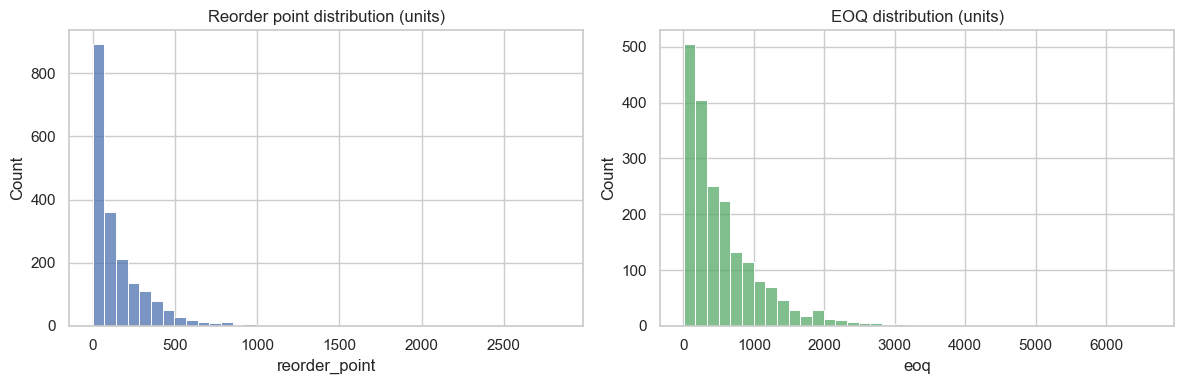

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(recommendations["reorder_point"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Reorder point distribution (units)")
sns.histplot(recommendations["eoq"], bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("EOQ distribution (units)")
plt.tight_layout()
plt.show()

## Reorder point

In [8]:
example = recommendations.sort_values("total_revenue", ascending=False).iloc[0]
print(f"Product: {example['description']} ({example.name})")
print(f"Reorder point: {example['reorder_point']:.0f} units, EOQ: {example['eoq']:.0f} units")
print()

for simulated_stock in [50, 200, 500]:
    result = simulate_reorder_trigger(simulated_stock, example["reorder_point"], example["eoq"])
    print(f"If current stock = {simulated_stock}: {result}")

Product: REGENCY CAKESTAND 3 TIER (22423)
Reorder point: 406 units, EOQ: 420 units

If current stock = 50: {'should_reorder': True, 'recommended_order_qty': 419.8386042481824}
If current stock = 200: {'should_reorder': True, 'recommended_order_qty': 419.8386042481824}
If current stock = 500: {'should_reorder': False, 'recommended_order_qty': 0.0}


## Day 10 findings summary

- Built ABC classification, safety stock, reorder point, and EOQ logic.
- ABC split: 21.1% of SKUs (1,034 products) drive 80% of revenue. Optimization
  effort is focused on tiers A+B (2,314 products); tier C (2,588 products,
  the long low-revenue tail) is excluded by design.
- Real bug caught before it shipped: one wholesale-scale transaction
  (80,995 units, a single product's only sale in its 90-day window)
  produced a reorder point of 43,247 units, about 7.7x its EOQ. Fixed by
  winsorizing per-transaction quantity at the global 99.9th percentile
  before computing demand statistics; the same product now gets a
  reorder point of 267 units, in line with its EOQ of 442.
